# **ASESMENT TENGAH SEMESTER / MUHAMMAD RIWDAN / 4222311005 / KELAS MALAM A / TEKNIK REKAYASA ROBOTIKA :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [ ]:
train = pd.read_csv('dataset_kecelakaan.csv')
train.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0


### Exploratory Data Analysis

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    300 non-null    int64 
 1   Usia                  300 non-null    int64 
 2   Jam_Kerja_per_Minggu  300 non-null    int64 
 3   Pengalaman_Tahun      300 non-null    int64 
 4   Pelatihan_K3          300 non-null    object
 5   Shift                 300 non-null    object
 6   Jabatan               300 non-null    object
 7   Lokasi                300 non-null    object
 8   Kecelakaan            300 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 21.2+ KB


In [ ]:
d = train.describe()
d

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Kecelakaan
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,40.376667,44.780000,17.746667,0.280000
std,86.746758,12.115448,6.597729,10.926747,0.449749
min,1.000000,15.000000,10.000000,1.000000,0.000000
25%,75.750000,30.000000,41.000000,8.000000,0.000000
50%,150.500000,42.000000,45.000000,18.000000,0.000000
75%,225.250000,51.000000,48.000000,27.000000,1.000000
max,300.000000,70.000000,100.000000,60.000000,1.000000


/tmp/ipykernel_9016/1680546196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Kecelakaan',data=train,palette='RdBu_r')


<Axes: xlabel='Kecelakaan', ylabel='count'>

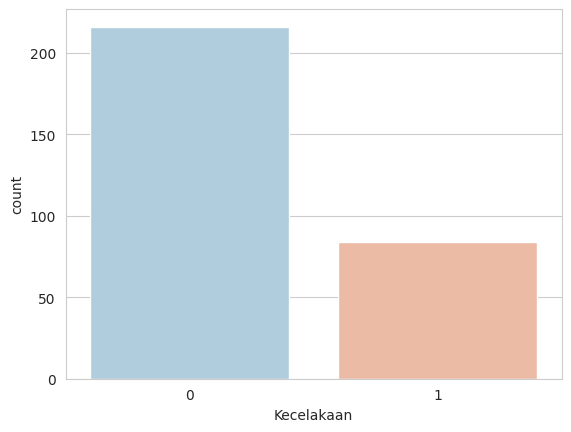

In [ ]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='Kecelakaan',data=train,palette='RdBu_r')

<Axes: xlabel='Kecelakaan', ylabel='count'>

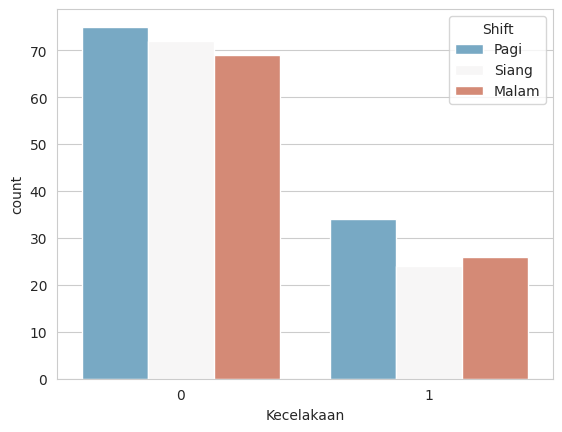

In [ ]:
# Survivability vs Shift
sns.set_style('whitegrid')
sns.countplot(x='Kecelakaan',hue='Shift',data=train,palette='RdBu_r')

<Axes: xlabel='Kecelakaan', ylabel='count'>

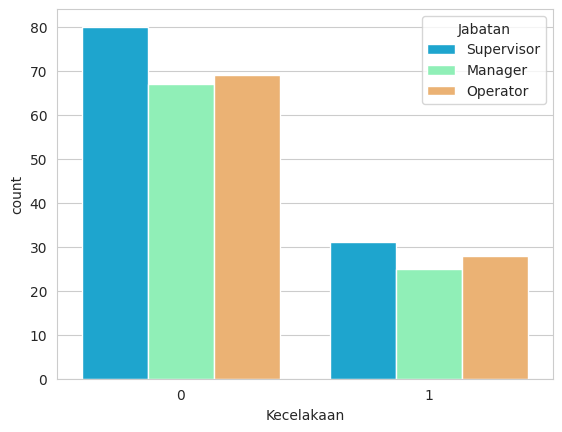

In [ ]:
# Survivability vs Jabatan
sns.set_style('whitegrid')
sns.countplot(x='Kecelakaan',hue='Jabatan',data=train,palette='rainbow')

Text(0.5, 1.0, 'Persentase kecelakaan berdasarkan Jabatan')

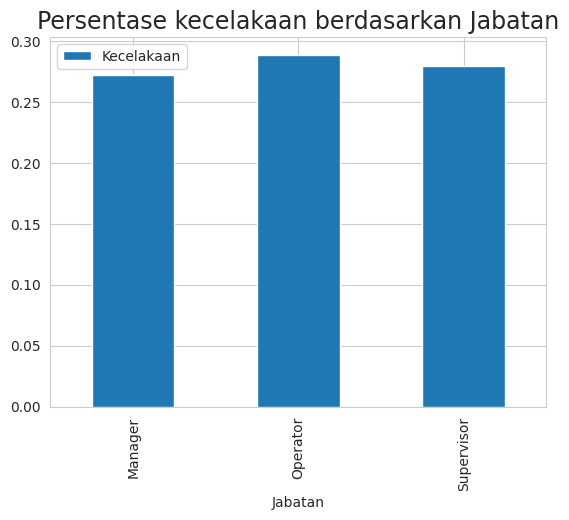

In [ ]:
f_class_accident=train.groupby('Jabatan')['Kecelakaan'].mean()
f_class_accident = pd.DataFrame(f_class_accident)
f_class_accident
f_class_accident.plot.bar(y='Kecelakaan')
plt.title("Persentase kecelakaan berdasarkan Jabatan",fontsize=17)

<Axes: xlabel='Kecelakaan', ylabel='count'>

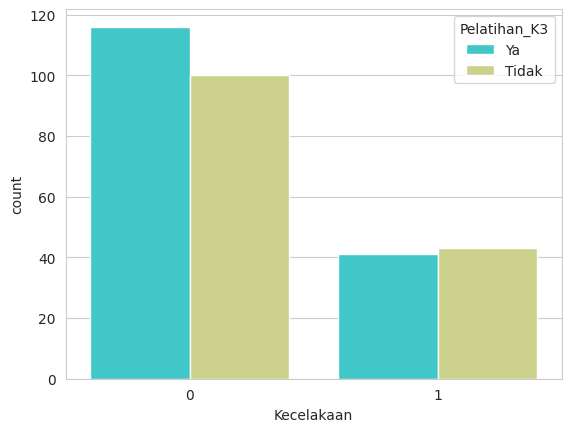

In [ ]:
# Kecelakaan vs Pelatihan_K3
sns.set_style('whitegrid')
sns.countplot(x='Kecelakaan',hue='Pelatihan_K3',data=train,palette='rainbow')

<Axes: title={'center': 'Histogram usia penumpang'}, xlabel='Usia penumpang', ylabel='Count'>

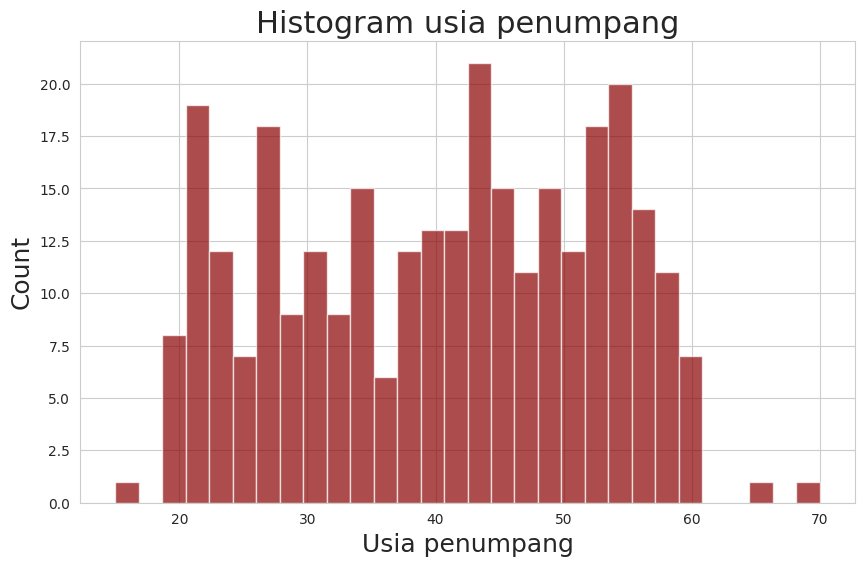

In [ ]:
# Cek distribusi dari umur
plt.xlabel("Usia penumpang",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram usia penumpang",fontsize=22)
train['Usia'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

/tmp/ipykernel_9016/1958863432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Jabatan',y='Usia',data=train,palette='winter')


<Axes: xlabel='Jabatan', ylabel='Usia'>

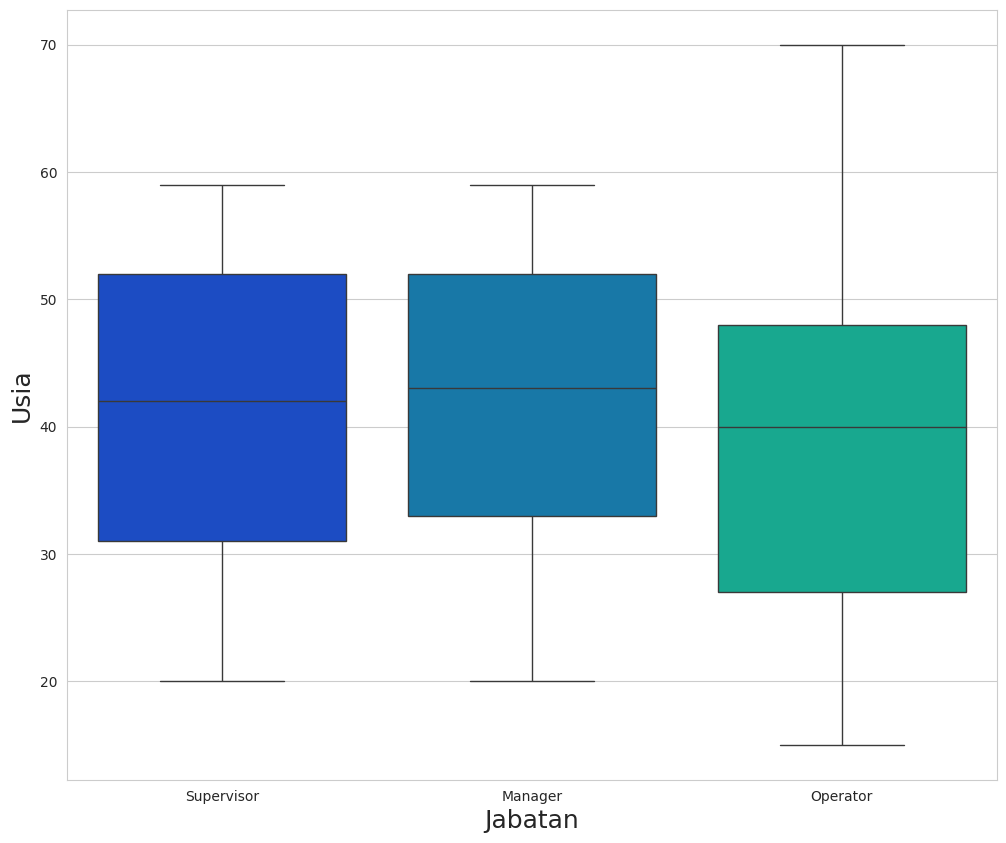

In [ ]:
# Distribusi umur di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("Jabatan",fontsize=18)
plt.ylabel("Usia",fontsize=18)
sns.boxplot(x='Jabatan',y='Usia',data=train,palette='winter')

Text(0.5, 0, 'Jabatan Karyawan')

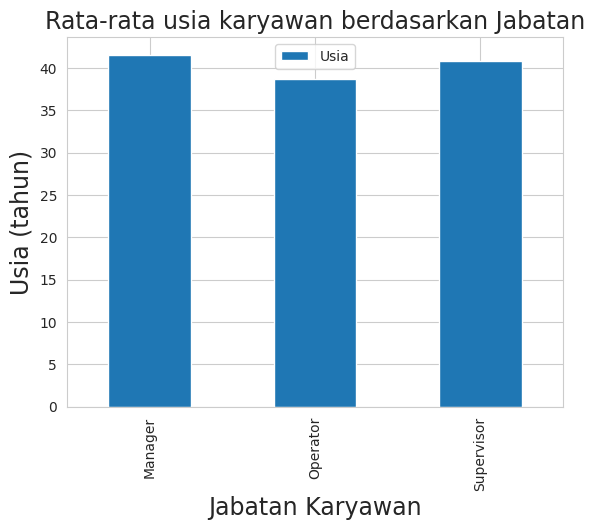

In [ ]:
f_class_Age=train.groupby('Jabatan')['Usia'].mean()
f_class_Age = pd.DataFrame(f_class_Age)
f_class_Age.plot.bar(y='Usia')
plt.title("Rata-rata usia karyawan berdasarkan Jabatan",fontsize=17)
plt.ylabel("Usia (tahun)", fontsize=17)
plt.xlabel("Jabatan Karyawan", fontsize=17)

### Fitur Engineering

In [ ]:
a=list(f_class_Age['Usia'])

def impute_age(cols):
    Usia = cols[0]
    Jabatan = cols[1]

    # This imputation logic is designed for the 'Titanic' dataset (Age/Pclass)
    # and is not strictly necessary for 'dataset_kecelakaan.csv' as 'Usia' has no missing values.
    # Also, the Pclass conditions (1, 2, 3) do not apply to 'Jabatan' values.

    if pd.isnull(Usia):
        # As 'Usia' has no nulls in this dataset, this block won't be executed.
        # If it were needed, the logic would need to be adapted for 'Jabatan' categories.
        if Jabatan == 'Manager':
            return a[0]
        elif Jabatan == 'Operator':
            return a[1]
        else:
            return a[2]
    else:
        return Usia

In [ ]:
train['Usia'] = train[['Usia', 'Jabatan']].apply(impute_age, axis=1)

/tmp/ipykernel_9016/1587314546.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Usia = cols[0]
/tmp/ipykernel_9016/1587314546.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Jabatan = cols[1]


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

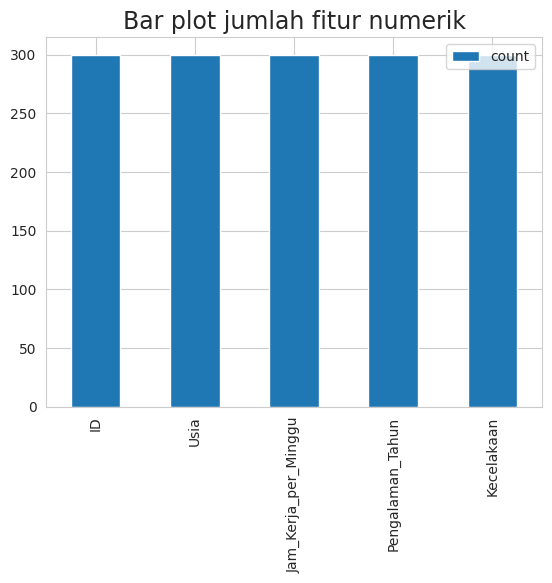

In [ ]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode categorical features present in the current dataset
train['Pelatihan_K3'] = le.fit_transform(train['Pelatihan_K3'])
train['Shift'] = le.fit_transform(train['Shift'])
train['Jabatan'] = le.fit_transform(train['Jabatan'])
train['Lokasi'] = le.fit_transform(train['Lokasi'])

train.head()

,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,58,47,10,1,1,2,0,0
1,48,44,17,0,2,2,0,0
2,34,40,22,1,1,0,0,0
3,27,37,26,0,0,0,0,0
4,40,42,25,0,1,2,0,0


### Training

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Kecelakaan',axis=1),
                                                    train['Kecelakaan'], test_size=0.30,
                                                    random_state=42)

In [ ]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (210, 7)
Test shape: (90, 7)


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = clf1.predict(X_test)

### Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.68
Confusion Matrix:
[[56  7]
 [22  5]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.89      0.79        63
           1       0.42      0.19      0.26        27

    accuracy                           0.68        90
   macro avg       0.57      0.54      0.53        90
weighted avg       0.63      0.68      0.63        90



# **Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Model Naive Bayes: 0.68
Confusion Matrix:
[[61  2]
 [27  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.97      0.81        63
           1       0.00      0.00      0.00        27

    accuracy                           0.68        90
   macro avg       0.35      0.48      0.40        90
weighted avg       0.49      0.68      0.57        90



# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 0.58
Confusion Matrix:
[[41 22]
 [16 11]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.65      0.68        63
           1       0.33      0.41      0.37        27

    accuracy                           0.58        90
   macro avg       0.53      0.53      0.53        90
weighted avg       0.60      0.58      0.59        90



Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [ ]:

new_data = np.array([[3, 0, 25.0, 0, 0, 7.25, 2]])

# Prediksi kelas
new_prediction = nb.predict(new_data)
print("Prediksi Kelangsungan Hidup (0 = Tidak Selamat, 1 = Selamat):", new_prediction[0])

# Prediksi probabilitas
proba = nb.predict_proba(new_data)
print("Probabilitas Prediksi [Tidak Selamat, Selamat]:", proba[0])

Prediksi Kelangsungan Hidup (0 = Tidak Selamat, 1 = Selamat): 1
Probabilitas Prediksi [Tidak Selamat, Selamat]: [0.09598913 0.90401087]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [ ]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.69
Confusion Matrix:
[[56  7]
 [21  6]]
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.89      0.80        63
           1       0.46      0.22      0.30        27

    accuracy                           0.69        90
   macro avg       0.59      0.56      0.55        90
weighted avg       0.65      0.69      0.65        90



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.685714   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.685714   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.685714   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.685714   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.695238   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.666667   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.723810   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.690476   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.661905   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.695238   
10  {'metric': 'manhattan', 'n_neighbors

In [ ]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [ ]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


In [ ]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.68
Presisi:  0.58
Recall:   0.56
F1-Score: 0.56

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.86      0.79        63
           1       0.44      0.26      0.33        27

    accuracy                           0.68        90
   macro avg       0.58      0.56      0.56        90
weighted avg       0.64      0.68      0.65        90

Confusion Matrix:
[[54  9]
 [20  7]]


In [ ]:
import numpy as np

# Data
new_data_1 = np.array([[3, 0, 25.0, 0, 0, 7.25, 2]])

# Prediksi
prediction = best_model.predict(new_data_1)

print("Prediksi (0 = Tidak Selamat, 1 = Selamat):", prediction[0])

Prediksi (0 = Tidak Selamat, 1 = Selamat): 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# **2. Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari studi kasus masing-masing.**

Feature engineering itu adalah seni mengubah data mentah jadi bentuk yang lebih 'enak' diproses oleh model machine learning. - Tujuannya : supaya model kita bisa belajar lebih efektif dan hasil prediksinya jadi lebih akurat. ini membantu mengatasi masalah data seperti nilai yang hilang atau data kategori yang belum bisa langsung dipahami oleh komputer.

Nah, kalau di studi kasus kita yang pakai data kecelakaan ini, contoh paling jelasnya ada di bagian mengubah data teks jadi angka. Kolom-kolom kayak Pelatihan_K3, Shift, Jabatan, sama Lokasi kan awalnya cuma tulisan biasa. Dengan label encoding, kita ubah 'Ya' jadi 1, 'Tidak' jadi 0, atau 'Pagi', 'Siang', 'Malam' jadi angka 0, 1, 2. Ini penting banget karena model seperti KNN atau Naive Bayes itu butuh masukan berupa angka. Selain itu, ada juga upaya imputasi Usia berdasarkan Jabatan yang sebenarnya untuk mengisi data yang mungkin kosong, meskipun di dataset ini kebetulan datanya lengkap semua.




# **3. Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing, Jelaskan?**

“Dalam mengevaluasi model klasifikasi, biasanya digunakan Confusion Matrix. Confusion Matrix merupakan tabel yang merangkum hasil prediksi model dengan membandingkannya terhadap kondisi sebenarnya. Pada tabel ini terdapat empat skenario utama, yaitu True Positive (TP) ketika model berhasil memprediksi adanya kecelakaan dengan benar, True Negative (TN) ketika model berhasil memprediksi tidak adanya kecelakaan, False Positive (FP) ketika model memprediksi ada kecelakaan padahal sebenarnya tidak terjadi, serta False Negative (FN) ketika model gagal mendeteksi kecelakaan yang sebenarnya terjadi. Melalui Confusion Matrix, dapat diketahui kekuatan dan kelemahan model, khususnya dalam kasus prediksi kecelakaan pada dataset yang digunakan.

Berdasarkan Confusion Matrix tersebut, kemudian dihitung beberapa metrik evaluasi yang lebih spesifik. Akurasi digunakan untuk melihat seberapa sering model memberikan prediksi yang benar secara keseluruhan. Presisi digunakan untuk menilai seberapa akurat prediksi ‘ada kecelakaan’, sehingga dapat meminimalkan kesalahan berupa alarm palsu. Recall digunakan untuk mengukur kemampuan model dalam mendeteksi seluruh kasus kecelakaan agar tidak ada kejadian yang terlewat. Selain itu, F1-Score digunakan karena mampu memberikan penilaian yang lebih seimbang, terutama ketika jumlah data kecelakaan dan non-kecelakaan tidak seimbang. Dengan metrik-metrik tersebut, efektivitas model dalam memprediksi kecelakaan dapat dievaluasi secara lebih menyeluruh.”